# Conceptual design: Two tubes

In [57]:
import numpy as np
import math as math
from scipy import optimize
from scipy import integrate as scint
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Define constants

In [58]:
g = 9.81 #m/s2
rhoW = 1025 #kg/m3

## Tunnel Properties

| Fig : Tunnel schematic  |
| :--- |
| <img width="70%" src="./img/nb03_singleTube.png" /> |
| <img width="100%" src="./img/nb03_twoTube.png" /> |

In [80]:
L = 11000 #m Length of the crossing (og: 3700m)

E = 36e9 #Pa 36GPa as per the Table 2 in Deng (2022)


D_out = 12.7 #m Outer diameter (og: 12.6m)
D_in = 11.3 #m Inner Diameter   (og: 11.0m)

dist_c2c = 15 #m centre to centre spacing for tubes

### Values per tube

In [81]:
A0 = np.pi/4*(D_out**2 - D_in**2)

I0 = np.pi/64*(D_out**4 - D_in**4)


print("Values per tube")
print("Outer Area = ", np.pi/4*(D_out**2), "m2")
print("Inner Area = ", np.pi/4*(D_in**2), "m2")
print("A0 = ", A0, "m2")
print("I0 = ", I0, "m4")



Values per tube
Outer Area =  126.67686977437442 m2
Inner Area =  100.28749148422018 m2
A0 =  26.389378290154248 m2
I0 =  476.62515864304817 m4


### Values for the system

In [82]:
As = 2*A0

Is = 2*( I0 + A0 * ((dist_c2c/2)**2) )

EI = E*Is

y_max = dist_c2c/2 + D_out/2 # For max longitudinal stress due to bending moment

print("As = ", As, "m2")
print("Is = ", Is, "m4")
print("EI = ", EI/1e9, "G m2")

As =  52.778756580308496 m2
Is =  3922.055374928449 m4
EI =  141193.99349742415 G m2


## Load calculation

- Current uniformly distributed load (UDL)
- We take Cd = 0.75
- We consider the sheltering effect for the two tube scenario

$$
w_{drag} = \frac{1}{2} \rho_w \, C_d \, D_{outer} \, \vec{U} | \vec{U} |
$$


In [83]:
Uinf = 0.8 #m/s
Cd = 0.75

shelter = (1 - 2*0.95*np.sqrt( (Cd * D_out) / (dist_c2c + 6*D_out) ) )
print("Shelter coeff = ", shelter)

wDrag_1 = 1/2 * rhoW * Cd * D_out * Uinf*abs(Uinf)
wDrag_2 = shelter * wDrag_1

wDrag = wDrag_1 + wDrag_2

print("Drag UDL on Tunnel 1 ", wDrag_1, "N/m")
print("Drag UDL on Tunnel 2 ", wDrag_2, "N/m")
print("Drag UDL Total ", wDrag, "N/m")

Shelter coeff =  0.38597129545924325
Drag UDL on Tunnel 1  3124.2000000000003 N/m
Drag UDL on Tunnel 2  1205.851521273768 N/m
Drag UDL Total  4330.051521273768 N/m


## Elastic Deflection: Only structural stiffness

- Here the external force is assumed to be a uniformly distributed load due to the drag from a constant current.
- Without the presence of mooring systems or other mechanisms, this external load is resisted only by the structural stiffness of the beam

$$
F_{drag} = \int_0^L \, \mathbf{K}_{str} \, v 
$$
$$
\text{where} \quad F_{drag} = \int_0^L \, w_{drag} \, dl
$$

- Assume the tunnel to be a simply supported beam
- For this load scenario, we can obtain the deflection of the beam using the following formula.

| Fig : Deflection of beam due to uniformly distributed load (UDL) <br> Ref: Hibbeler, R.C., 2011. Mechanics of materials, 8th ed. ed. Prentice Hall, Boston. Appendix C |
| :--- |
| <img width="100%" src="./img/nb03_udl_formula_1.png" /> |




In [84]:
FDrag = wDrag * L

udl = wDrag

print("Drag UDL ", wDrag, "N/m")
print("Drag Force ", FDrag/1e6, "MN")

Drag UDL  4330.051521273768 N/m
Drag Force  47.63056673401145 MN


v Max =  5846.370880763102  m


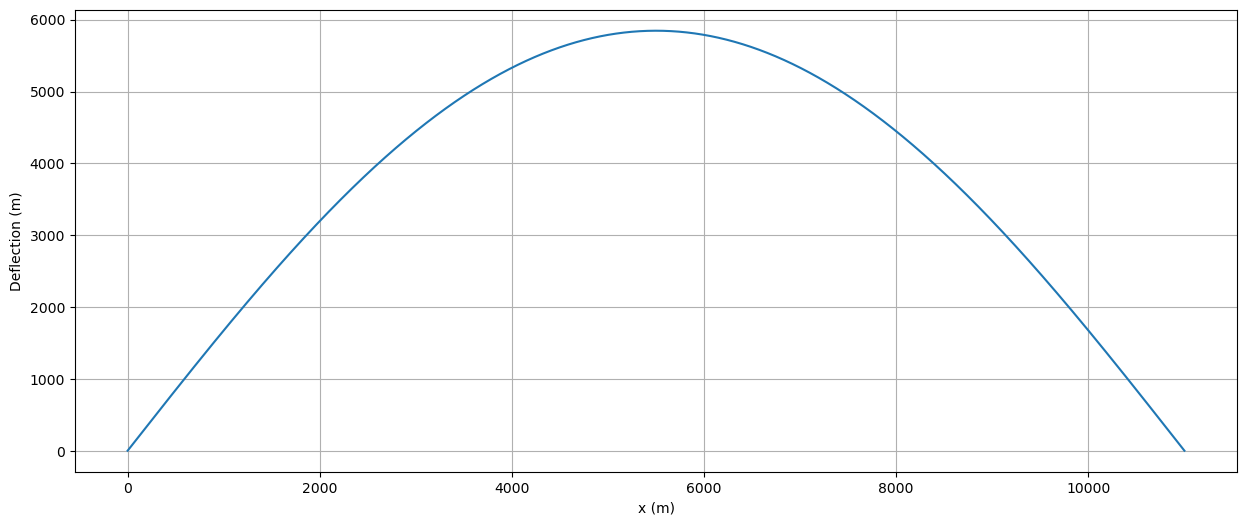

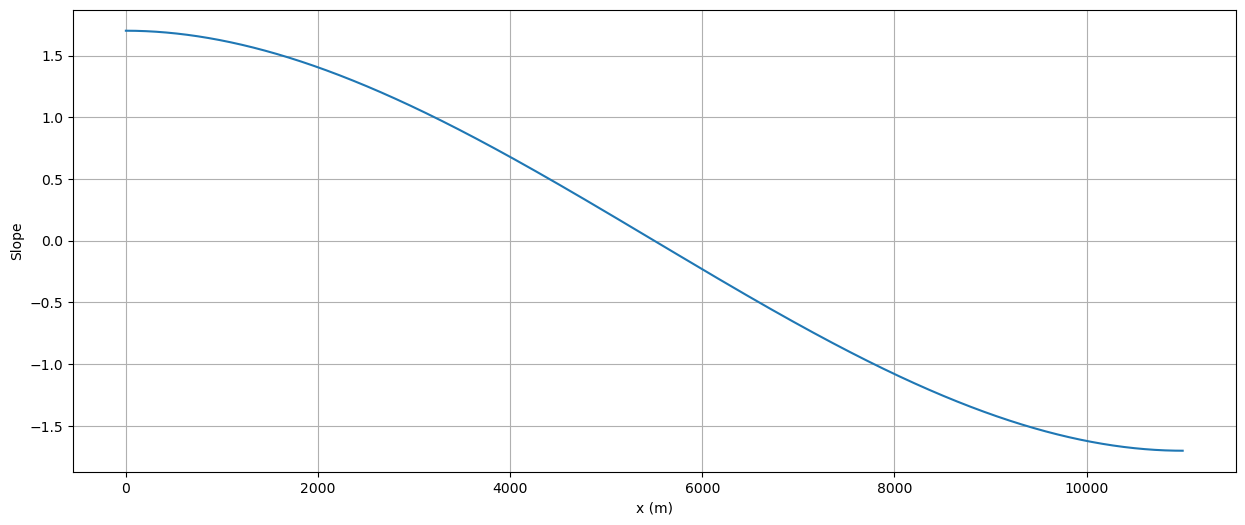

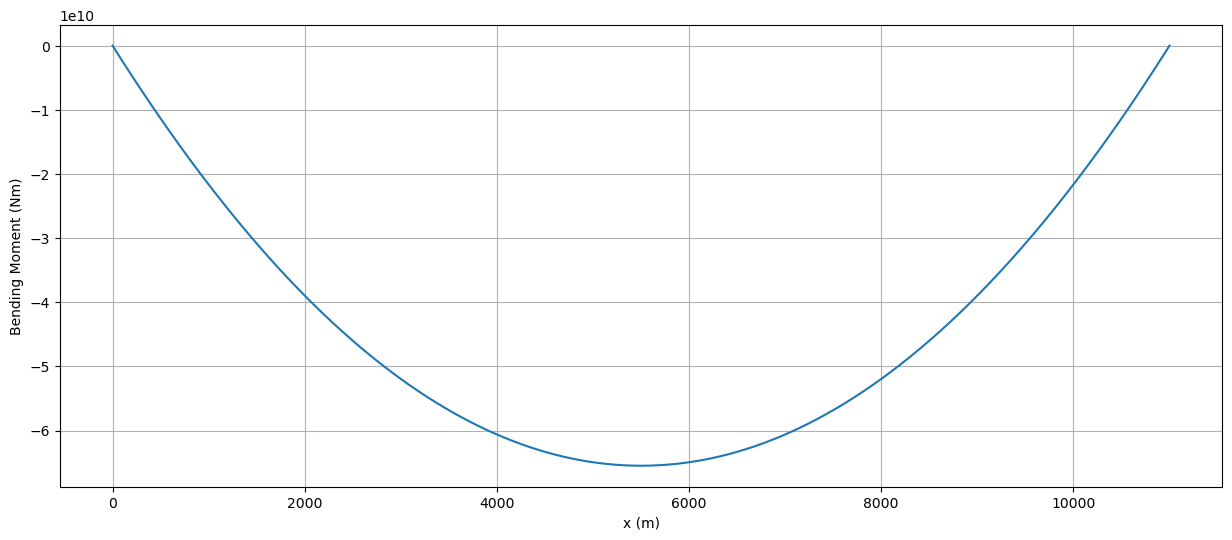

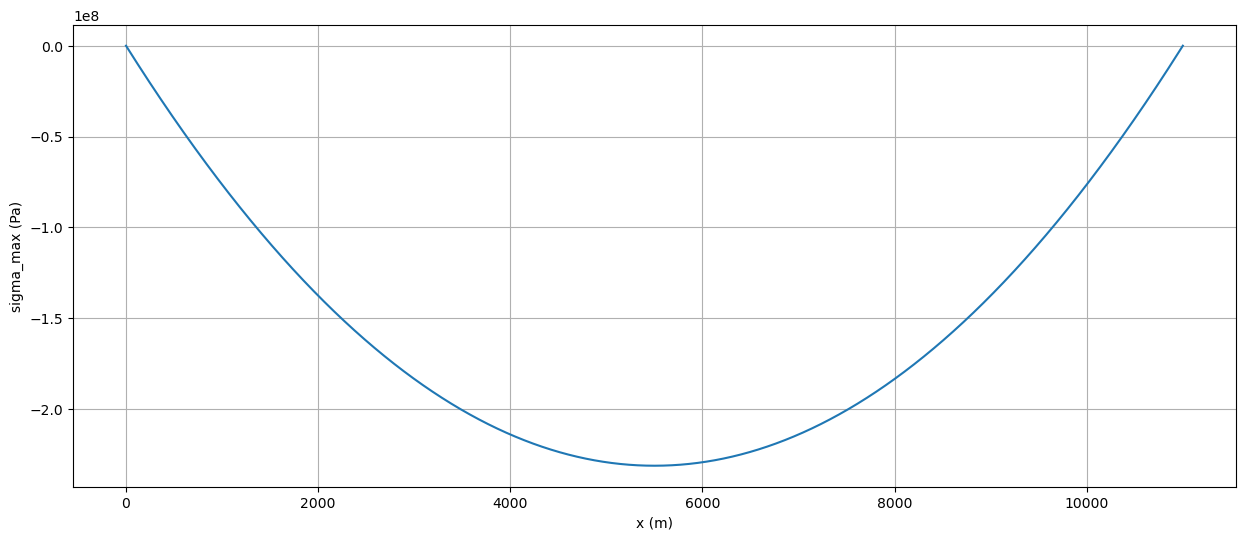

In [85]:
x = np.arange(0, L+0.5, 0.5)


v = [ udl*lx/24/EI*(lx**3 - 2*L*lx**2 + L**3) for lx in x ]
vx = [ udl/24/EI*(4*lx**3 - 6*L*lx**2 + L**3) for lx in x ]
vxx = [ udl/2/EI*(lx**2 - L*lx) for lx in x ]
BM = [ udl/2*(lx**2 - L*lx) for lx in x ]
sig_max = [ lbm * y_max/Is  for lbm in BM ]


print("v Max = ",max(np.abs(v)), " m")


plt.figure(1)
plt.plot(x, v)
plt.xlabel("x (m)")
plt.ylabel("Deflection (m)")
plt.grid()

plt.figure(2)
plt.plot(x, vx)
plt.xlabel("x (m)")
plt.ylabel("Slope")
plt.grid()

plt.figure(3)
plt.plot(x, BM)
plt.xlabel("x (m)")
plt.ylabel("Bending Moment (Nm)")
plt.grid()

plt.figure(4)
plt.plot(x, sig_max)
plt.xlabel("x (m)")
plt.ylabel("sigma_max (Pa)")
plt.grid()
plt.show()

pass

## Elastic Deflection: Structural stiffness + Mooring stiffness

- The structural stiffness is not sufficient for resisting the drag load
- We add mooring lines for providing additional stiffness to the system and reduce the stresses within the structure.
- Let us say we have $n_M$ mooring lines, having linear surge stiffness of $k_M$ per line.
- The total resistance provided by the mooring system is

$$
F_{moor} = -\sum_{i=1}^{n_M} k_M \, v(x_i)
$$

- Here, $x_i$ is the position where the $i^{th}$ mooring line is connected to the tunnel.
- For the sake of the conceptual design, we assume that the restoring force from the mooring system is a uniformly distributed load $w_{moor}$

$$
w_{moor} = \frac{F_{moor}}{L} = \frac{-1}{L} \sum_{i=1}^{n_M} k_M \, v(x_i)
$$

- Therefore, the net load on the tunnel is

$$
F_{drag} + F_{moor} = \int_0^L \, \mathbf{K}_{str} \, v 
$$
$$
\implies \int_0^L w_{drag} \, dl + \int_0^L w_{moor} \, dl = \int_0^L \, \mathbf{K}_{str} \, v 
$$
$$
\implies \int_0^L w_{drag} \, dl - \sum_{i=1}^{n_M} k_M \, v(x_i) = \int_0^L \, \mathbf{K}_{str} \, v 
$$




In [98]:
FDrag = wDrag * L

FMoor = - 0.97 * FDrag
wMoor = FMoor / L

udl = wDrag + wMoor


print("Drag UDL ", wDrag, "N/m")
print("Drag Force ", FDrag/1e6, "MN")
print("Mooring Force ", FMoor/1e6, "MN")
print()
print("Drag UDL ", wDrag, "N/m")
print("Mooring UDL ", wMoor, "N/m")
print("Net UDL ", udl, "N/m")

Drag UDL  4330.051521273768 N/m
Drag Force  47.63056673401145 MN
Mooring Force  -46.201649731991104 MN

Drag UDL  4330.051521273768 N/m
Mooring UDL  -4200.149975635555 N/m
Net UDL  129.90154563821307 N/m


v Max =  175.39112642289308  m


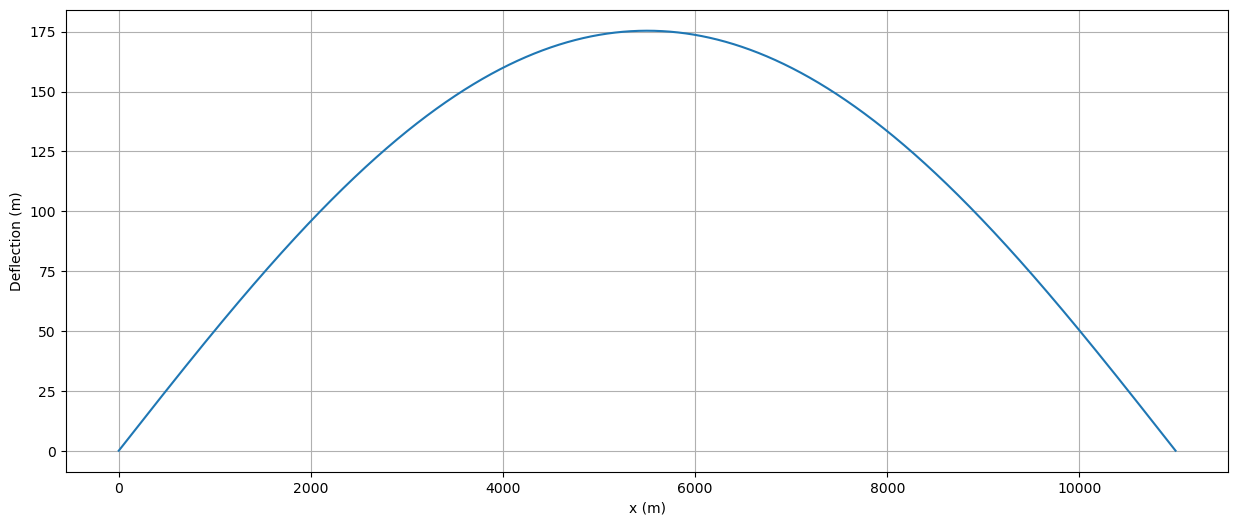

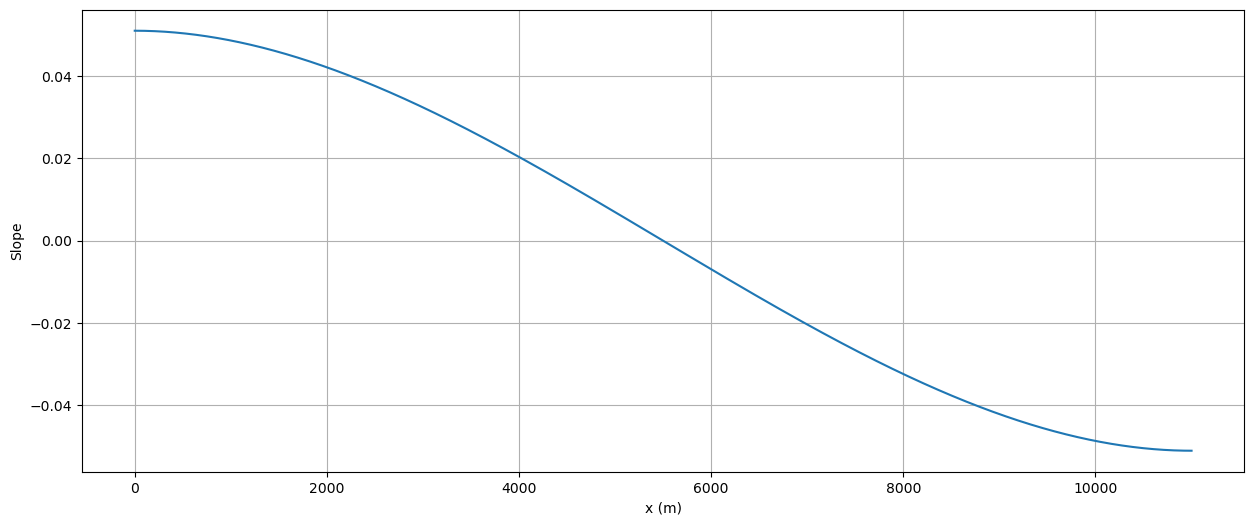

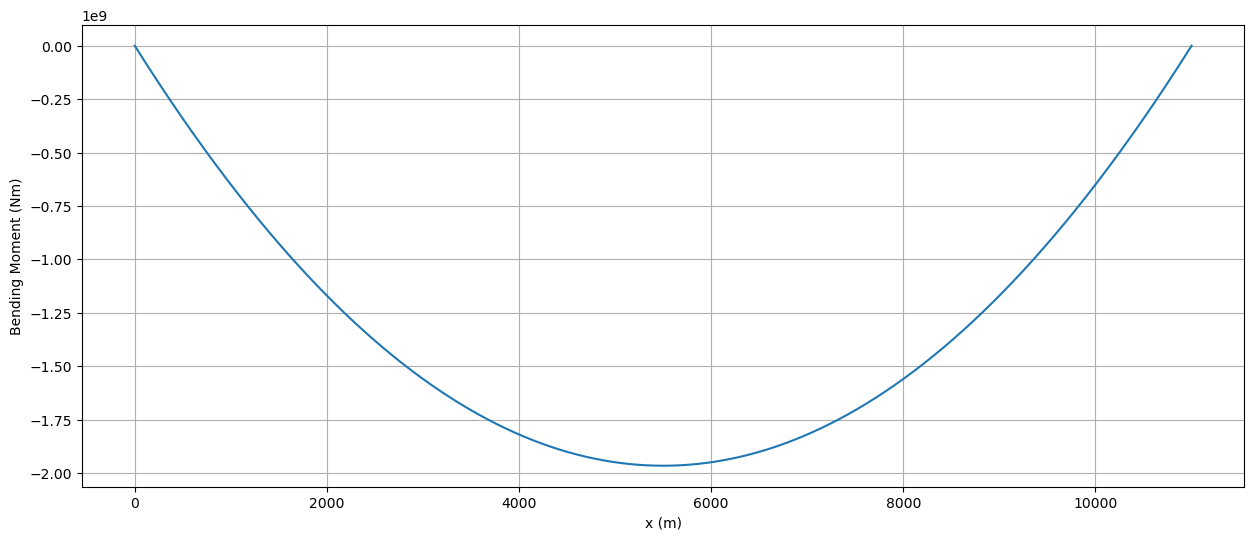

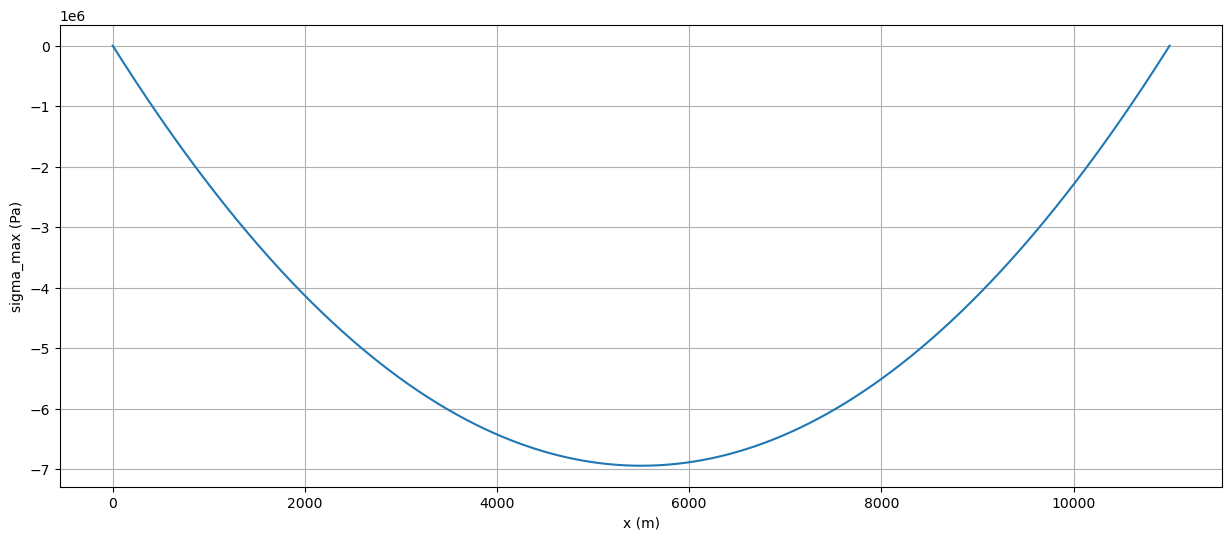

In [99]:
x = np.arange(0, L+0.5, 0.5)

v = [ udl*lx/24/EI*(lx**3 - 2*L*lx**2 + L**3) for lx in x ]
vx = [ udl/24/EI*(4*lx**3 - 6*L*lx**2 + L**3) for lx in x ]
vxx = [ udl/2/EI*(lx**2 - L*lx) for lx in x ]
BM = [ udl/2*(lx**2 - L*lx) for lx in x ]
sig_max = [ lbm * y_max/Is  for lbm in BM ]


print("v Max = ",max(np.abs(v)), " m")


plt.figure(5)
plt.plot(x, v)
plt.xlabel("x (m)")
plt.ylabel("Deflection (m)")
plt.grid()

plt.figure(6)
plt.plot(x, vx)
plt.xlabel("x (m)")
plt.ylabel("Slope")
plt.grid()

plt.figure(7)
plt.plot(x, BM)
plt.xlabel("x (m)")
plt.ylabel("Bending Moment (Nm)")
plt.grid()

plt.figure(8)
plt.plot(x, sig_max)
plt.xlabel("x (m)")
plt.ylabel("sigma_max (Pa)")
plt.grid()
plt.show()

pass

## Mooring system: Number of mooring lines

$$
F_{moor} = -\sum_{i=1}^{n_M} k_M \, v(x_i)
$$

- In order to achieve the restoring force from the mooring system, we need to play with $n_M$ and $k_M$
- Let us assume that the mooring lines are attached at regular intervals along the line.
- Then the position of each mooring line along the tunnel is 

$$
x_i = \frac{i}{n_M+1} L
$$

- From the above calculation, we have the deflection profile of the beam $v(x)$.
- We will use these to estimate the surge excursion of the $i^{th}$, i.e., $v(x_i)$ and hence obtain the restoring force due to $i^{th}$ mooring line, i.e., $-k_M \, v(x_i)$


v Max =  175.39112642289308  m
Mooring Line positions 
[275.0, 550.0, 825.0, 1100.0, 1375.0, 1650.0, 1924.9999999999998, 2200.0, 2475.0, 2750.0, 3025.0000000000005, 3300.0, 3575.0, 3849.9999999999995, 4125.0, 4400.0, 4675.0, 4950.0, 5225.0, 5500.0, 5775.0, 6050.000000000001, 6324.999999999999, 6600.0, 6875.0, 7150.0, 7425.000000000001, 7699.999999999999, 7975.0, 8250.0, 8525.0, 8800.0, 9075.0, 9350.0, 9625.0, 9900.0, 10175.0, 10450.0, 10725.0]

Required Mooring Force -46.201649731991104 MN
Obtained Mooring Force -53.852087949062565 MN


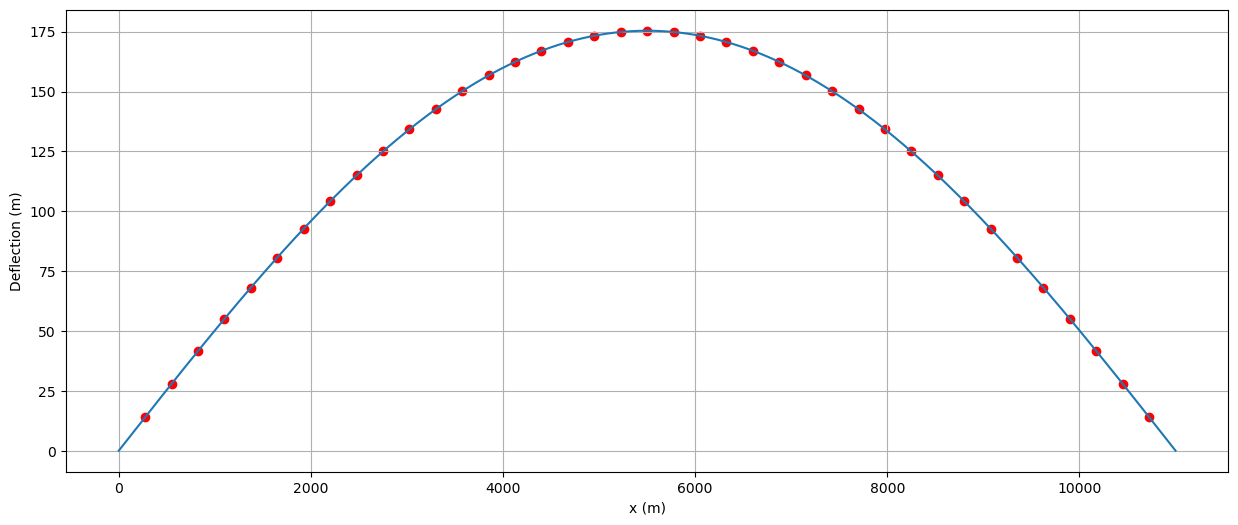

In [106]:
x = np.arange(0, L+0.5, 0.5)


udl = wDrag + wMoor
v = [ udl*lx/24/EI*(lx**3 - 2*L*lx**2 + L**3) for lx in x ]

print("v Max = ",max(np.abs(v)), " m")

## Mooring

nM = 39 # number of mooring lines
kM = 12e3 #N/m (og: 12kN/m) (e3 kN/m)

x_i = [ (i+1)/(nM+1)*L for i in range(nM)]
print("Mooring Line positions ")
print(x_i)
print()


# Deflection at these positions
v_i = [ udl*lx/24/EI*(lx**3 - 2*L*lx**2 + L**3) for lx in x_i ]


# Mooring system restoring force
FMoor_perLine = [ -kM*iv for iv in v_i ]
FMoor_obtained = sum(FMoor_perLine)

print("Required Mooring Force", FMoor/1e6, "MN")
print("Obtained Mooring Force", FMoor_obtained/1e6, "MN")

plt.figure()
plt.plot(x, v)
plt.scatter(x_i, v_i, color='red')
plt.xlabel("x (m)")
plt.ylabel("Deflection (m)")
plt.grid()
plt.show()
pass